## Практическая работа

### Описание датасета:



- `id`: идентификатор записи;
- `url`: URL записи о продаже;
- `region`: регион;
- `region_url`: URL региона;
- `price`: стоимость;
- `year`: год выпуска;
- `manufacturer`: производитель;
- `model`: модель;
- `fuel`: тип топлива;
- `odometer`: количество пройденных миль;
- `title_status`: статус;
- `transmission`: коробка передач;
- `image_url`: URL изображения;
- `description`: указанное описание;
- `state`: штат;
- `lat`: широта;
- `long`: долгота;
- `posting_date`: дата размещения объявления о продаже;
- `price_category`: категория цены;
- `date`: дата публикации.

In [1]:
# Импорт необходимых библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import pickle

In [2]:
# Загрузка датасета и его размерность 

df = pd.read_csv('../data/df_out.csv')
df.shape

(10000, 20)

In [3]:
# Вывод первых 5 строк датафрейма

df.head()

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020.0,ram,2500 crew cab big horn,diesel,27442,clean,other,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high,2021-04-17 16:30:50+00:00
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016.0,ford,explorer 4wd 4dr xlt,NaN,60023,clean,automatic,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium,2021-05-03 19:40:21+00:00
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017.0,volkswagen,golf r hatchback,gas,14048,clean,other,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high,2021-04-28 10:52:20+00:00
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013.0,toyota,rav4,gas,117291,clean,automatic,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium,2021-04-17 14:08:57+00:00
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021.0,nissan,altima,gas,8000,clean,automatic,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium,2021-05-03 22:32:06+00:00


# Data Preparation

In [4]:
# Создадим копию датафрейма для дальнейшей обработки и выведем список колонок

df_clean = df.copy()
df_clean.columns.tolist()

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'image_url',
 'description',
 'state',
 'lat',
 'long',
 'posting_date',
 'price_category',
 'date']

In [5]:
# Проверим на дубликаты

df_clean.duplicated().sum()

np.int64(0)

In [6]:
# Удалим ненужные признаки для нашей модели 

drops_list = ['id', 'url', 'region_url', 'price', 'image_url', 'posting_date']


df_clean = df_clean.drop(drops_list, axis=1, errors='ignore')

## Обработка пропусков

In [7]:
# Посмотрим в целом на пропуски

df_clean[df_clean.isnull().any(axis=1)].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
1,north jersey,2016.0,ford,explorer 4wd 4dr xlt,NaN,60023,clean,automatic,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,medium,2021-05-03 19:40:21+00:00
11,cincinnati,2012.0,fiat,500 pop,gas,59242,NaN,manual,"2012 Fiat 500 Pop FOR ONLY $102/mo!59,242 mi. ...",oh,39.297045,-84.563243,low,2021-05-04 01:03:32+00:00
32,eugene,2001.0,toyota,camry solara 2dr cpe se v6 auto (natl),NaN,193242,clean,automatic,***Call Us for more information at: 541-228-94...,or,44.076513,-123.150156,low,2021-04-20 17:40:15+00:00
67,ventura county,2005.0,rover,NaN,gas,165206,clean,automatic,2005 Range Rover HSE Changed Oil and now engi...,ca,34.219565,-119.001986,low,2021-05-04 20:11:15+00:00
78,eugene,2009.0,ford,"f-150 4wd supercrew 145"" platinum",NaN,79522,clean,automatic,***Call Us for more information at: 541-228-94...,or,44.076513,-123.150156,high,2021-04-29 22:15:30+00:00


In [8]:
# Проверим кол-во пропусков в кажом столбце

def columns_blank(df):
    return df_clean.isnull().sum()

columns_blank(df_clean)

region              0
year               36
manufacturer        0
model             128
fuel               63
odometer            0
title_status      166
transmission       45
description         2
state               0
lat                98
long               98
price_category      0
date                2
dtype: int64

In [9]:
df_clean[df_clean.year.isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
344,wenatchee,NaN,other,500,gas,13508,clean,automatic,2019 *Ram* *1500* Big Horn/Lone Star 4x2 Quad ...,wa,47.434493,-120.320759,high,2021-04-09 13:31:03+00:00
420,las vegas,NaN,other,Super Duty F-350 SRW,diesel,1268,clean,automatic,2020 *Ford* *Super Duty F-350 SRW* 1K MILES. B...,nv,33.458277,-111.925970,high,2021-05-03 18:31:39+00:00
425,western slope,NaN,other,Grand Caravan,NaN,21,clean,automatic,"2019 *Dodge* *Grand Caravan* SE - $43,900Call ...",co,39.674406,-104.998604,high,2021-05-02 07:11:33+00:00
702,nashville,NaN,other,olet Silverado 1500,NaN,59246,NaN,automatic,2019 *Chevrolet* *Silverado 1500* 2019 CHEVROL...,tn,36.138022,-86.732261,high,2021-05-03 15:00:40+00:00
893,denver,NaN,other,F-150,gas,6110,clean,automatic,"2020 *Ford* *F-150* PLATINUM FX4 Truck - $60,9...",co,40.362248,-111.785947,high,2021-05-04 18:11:22+00:00


In [10]:
# Удалим почти пустые строки

df_clean = df_clean.drop([6728, 9388])

In [11]:
# Поищем year в description и заполним пропуски 

df_clean['year_from_desc'] = df_clean['description'].str.extract(r'(19\d{2}|20\d{2})')
df_clean.year = df_clean.year.fillna(df_clean['year_from_desc'])

df_clean = df_clean.drop(['year_from_desc'],axis=1)

In [12]:
# Проверим пропуски

columns_blank(df_clean)

region              0
year                0
manufacturer        0
model             126
fuel               61
odometer            0
title_status      164
transmission       43
description         0
state               0
lat                96
long               96
price_category      0
date                0
dtype: int64

In [13]:
# Пропуски в колонке model 

df_clean[df_clean.model.isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
67,ventura county,2005.0,rover,NaN,gas,165206,clean,automatic,2005 Range Rover HSE Changed Oil and now engi...,ca,34.219565,-119.001986,low,2021-05-04 20:11:15+00:00
142,chicago,2006.0,jeep,NaN,gas,132000,clean,automatic,SUPER CLEAN 2006 JEEP LIBEERY RANAGADE 4X4 O...,il,41.618957,-87.726334,low,2021-05-04 01:33:40+00:00
151,worcester / central MA,2007.0,gmc,NaN,gas,190000,clean,automatic,2007 gmc with plow leather loaded nice truck r...,ma,42.579600,-71.803100,low,2021-04-08 13:10:07+00:00
200,gainesville,2012.0,ram,NaN,gas,121371,clean,automatic,2012 RAM 1500 Laramie Crew Cab 2WD Offered...,fl,28.329026,-81.404237,medium,2021-05-01 14:05:17+00:00
251,reading,2007.0,ram,NaN,diesel,220019,clean,automatic,2007 Dodge Ram 2500 SLT 4x4 Quad Cab Cummins D...,pa,40.894535,-74.152367,medium,2021-05-03 01:06:09+00:00


In [14]:
# Заполним 'unknown' так как довольно таки тяжело вытащить из описания

df_clean.model = df_clean.model.fillna('Unknown')

In [15]:
columns_blank(df_clean)

region              0
year                0
manufacturer        0
model               0
fuel               61
odometer            0
title_status      164
transmission       43
description         0
state               0
lat                96
long               96
price_category      0
date                0
dtype: int64

In [16]:
df_clean[df_clean.fuel.isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
1,north jersey,2016.0,ford,explorer 4wd 4dr xlt,NaN,60023,clean,automatic,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,medium,2021-05-03 19:40:21+00:00
32,eugene,2001.0,toyota,camry solara 2dr cpe se v6 auto (natl),NaN,193242,clean,automatic,***Call Us for more information at: 541-228-94...,or,44.076513,-123.150156,low,2021-04-20 17:40:15+00:00
78,eugene,2009.0,ford,"f-150 4wd supercrew 145"" platinum",NaN,79522,clean,automatic,***Call Us for more information at: 541-228-94...,or,44.076513,-123.150156,high,2021-04-29 22:15:30+00:00
275,hawaii,2019.0,nissan,frontier crew cab 4x2 sv auto,NaN,10679,clean,automatic,***Call Us for more information at: 877-262-34...,hi,21.344376,-157.896975,high,2021-05-01 01:50:19+00:00
425,western slope,2019,other,Grand Caravan,NaN,21,clean,automatic,"2019 *Dodge* *Grand Caravan* SE - $43,900Call ...",co,39.674406,-104.998604,high,2021-05-02 07:11:33+00:00


In [17]:
df_clean.fuel = df_clean.fuel.fillna('Unknown')

In [18]:
columns_blank(df_clean)

region              0
year                0
manufacturer        0
model               0
fuel                0
odometer            0
title_status      164
transmission       43
description         0
state               0
lat                96
long               96
price_category      0
date                0
dtype: int64

In [19]:
df_clean[df_clean.title_status.isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
11,cincinnati,2012.0,fiat,500 pop,gas,59242,NaN,manual,"2012 Fiat 500 Pop FOR ONLY $102/mo!59,242 mi. ...",oh,39.297045,-84.563243,low,2021-05-04 01:03:32+00:00
187,orange county,2013.0,ram,1500 tradesman quad cab,gas,145499,NaN,automatic,2013 Ram 1500 Tradesman Quad Cab PRICED TO SEL...,ca,33.873436,-117.542806,medium,2021-04-27 22:03:47+00:00
245,ocala,2019.0,toyota,sienna xle,gas,3700,NaN,automatic,2019 Toyota Sienna - Wheelchair Accessible Han...,fl,27.849760,-82.364950,high,2021-05-01 10:35:56+00:00
286,toledo,2003.0,chevrolet,avalanche 1500,gas,268691,NaN,automatic,$73/mo - 2003 Chevrolet Avalanche 1500 BaseCre...,oh,42.300673,-84.024108,low,2021-04-14 16:03:01+00:00
312,roseburg,2017.0,ford,mustang,gas,66049,NaN,automatic,"2017 Ford MUSTANG - $18,450 \tMayberry Motors ...",or,44.058499,-123.106176,medium,2021-04-16 11:06:29+00:00


In [20]:
df_clean.title_status.value_counts(dropna=False)

title_status
clean         9518
rebuilt        171
NaN            164
salvage         92
lien            35
missing         16
parts only       2
Name: count, dtype: int64

In [21]:
df_clean.title_status = df_clean.title_status.fillna('clean')

In [22]:
columns_blank(df_clean)

region             0
year               0
manufacturer       0
model              0
fuel               0
odometer           0
title_status       0
transmission      43
description        0
state              0
lat               96
long              96
price_category     0
date               0
dtype: int64

In [23]:
df_clean[df_clean.transmission.isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
111,grand rapids,2013.0,lexus,es,gas,109382,clean,NaN,2013 Lexus ES 350 4dr Sdn Offered by: Auto...,mi,43.059210,-85.688970,medium,2021-04-11 13:41:58+00:00
112,south jersey,2012.0,jeep,wrangler,other,130174,clean,NaN,2012 Jeep Wrangler Unlimited Sport 4WD Off...,nj,40.135190,-74.703570,medium,2021-04-30 18:58:56+00:00
817,south jersey,2015.0,honda,civic,gas,79797,clean,NaN,2015 Honda Civic EX Offered by: VIP Auto O...,nj,39.938023,-74.971461,medium,2021-04-16 23:46:55+00:00
931,new hampshire,2018.0,ram,3500,other,8853,clean,NaN,2018 RAM Ram Chassis 3500 Short Wheelbase (Dua...,nh,42.834977,-71.107791,high,2021-04-30 14:15:30+00:00
970,poconos,2014.0,jeep,wrangler,gas,110493,clean,NaN,2014 Jeep Wrangler Unlimited Sport 4WD Off...,pa,40.135190,-74.703570,high,2021-04-30 21:46:04+00:00


In [24]:
df_clean.transmission.value_counts(dropna=False)

transmission
automatic    7700
other        1624
manual        631
NaN            43
Name: count, dtype: int64

In [25]:
df_clean.transmission = df_clean.transmission.fillna('other')

In [26]:
columns_blank(df_clean)

region             0
year               0
manufacturer       0
model              0
fuel               0
odometer           0
title_status       0
transmission       0
description        0
state              0
lat               96
long              96
price_category     0
date               0
dtype: int64

In [27]:
df_clean[df_clean['lat'].isnull()].head()

,region,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
118,tri-cities,2012.0,bmw,5 series,gas,62665,clean,automatic,2012 BMW 5 Series 535i M Sport Heat & Cool Sea...,tn,NaN,NaN,medium,2021-04-26 08:28:35+00:00
126,north jersey,2014.0,bmw,7 series,gas,81085,clean,automatic,2014 BMW 7 Series 4dr Sdn 750Li xDrive AWD Aut...,nj,NaN,NaN,high,2021-05-01 21:49:09+00:00
502,winston-salem,2016.0,ford,transit cargo,gas,123825,clean,automatic,2016 Ford Transit Cargo Vans Work Van High Roo...,nc,NaN,NaN,medium,2021-04-18 08:43:46+00:00
567,jacksonville,2014.0,mercedes-benz,c-class,gas,124476,clean,automatic,2014 Mercedes Benz C Class C 250 Sport Coupe C...,nc,NaN,NaN,medium,2021-04-19 16:06:28+00:00
692,atlanta,2008.0,toyota,tundra,gas,96000,clean,automatic,Description: 2008 Toyota Tundra 5...,ga,NaN,NaN,medium,2021-04-30 16:09:49+00:00


In [28]:
# Заполним пропуски long, lat средним значением из региона

df_clean.lat = df_clean.lat.fillna(df_clean.groupby('region')['lat'].transform('mean'))
df_clean.long = df_clean.long.fillna(df_clean.groupby('region')['long'].transform('mean'))

In [29]:
columns_blank(df_clean)

region            0
year              0
manufacturer      0
model             0
fuel              0
odometer          0
title_status      0
transmission      0
description       0
state             0
lat               0
long              0
price_category    0
date              0
dtype: int64

## Преобразование типов 

In [30]:
df_clean.dtypes

region                str
year               object
manufacturer          str
model                 str
fuel                  str
odometer            int64
title_status          str
transmission          str
description           str
state                 str
lat               float64
long              float64
price_category        str
date                  str
dtype: object

In [31]:
# Приведем признаки к нужным типам данных

df_clean['year'] = df_clean['year'].astype('int')
df_clean['date'] = pd.to_datetime(df_clean['date'])


In [32]:
df_clean.dtypes

region                            str
year                            int64
manufacturer                      str
model                             str
fuel                              str
odometer                        int64
title_status                      str
transmission                      str
description                       str
state                             str
lat                           float64
long                          float64
price_category                    str
date              datetime64[us, UTC]
dtype: object

## Поиск аномалий

In [33]:
df_clean.columns.tolist()

['region',
 'year',
 'manufacturer',
 'model',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'description',
 'state',
 'lat',
 'long',
 'price_category',
 'date']

In [34]:
def visualize_outliers(df, column):
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,7))
    
    ax1.hist(df[column], bins=100)
    ax1.set_title(f'Hist of {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('frequecy')
    
    ax2.boxplot(df[column], vert=False)
    ax2.set_title(f'Boxplot of {column}')
        
    plt.show();
    

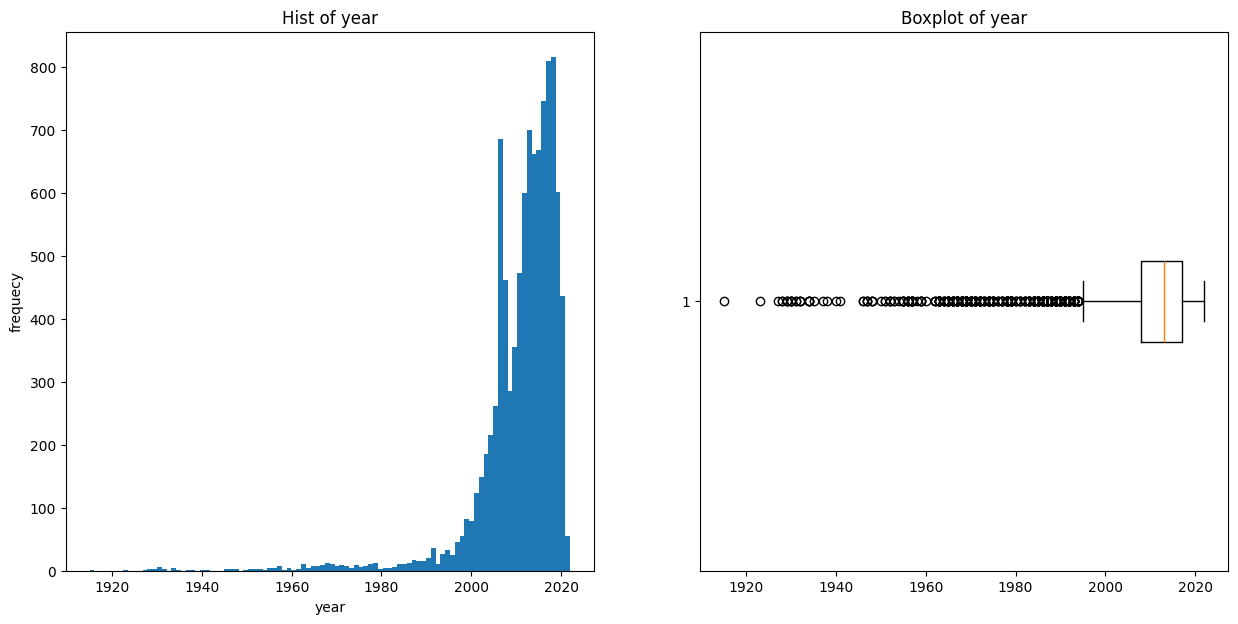

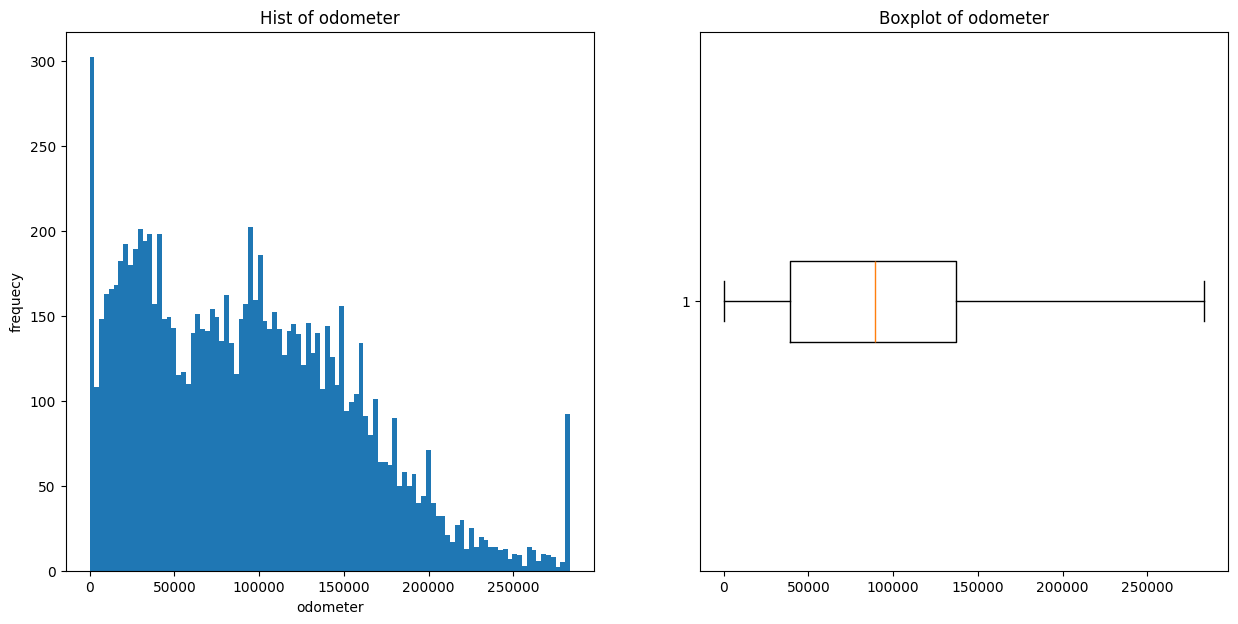

In [35]:
for column in ['year', 'odometer']:
    visualize_outliers(df_clean, column)

Признак год выпуска (year) характеризуется значительным количеством выбросов. Для повышения качества обучения модели было принято решение применить метод межквартильного размаха (IQR) для фильтрации аномалий. В то же время, признак одометр (odometer) не содержит критических выбросов и не требует предобработки

In [36]:
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    
    boundaries = (q1-1.5*iqr, q3+1.5*iqr)
    outliners = df[(df[column]<boundaries[0]) | (df[column]>boundaries[1])]
    
    df_filtered = df[(df[column] >= boundaries[0]) & (df[column] <= boundaries[1])]
    
    return df_filtered

In [37]:
df_clean = remove_outliers(df_clean, 'year')

In [38]:
df_clean.price_category.value_counts()

price_category
high      3417
medium    3144
low       3043
Name: count, dtype: int64

Данные для целевой переменной нормализированны

In [39]:
# Посмотрим на кол-во уникальных значений для важных признаков

for col in ['manufacturer', 'fuel', 'transmission', 'title_status']:
    print('-'*25)
    print(df_clean[col].value_counts())

-------------------------
manufacturer
ford               1578
chevrolet          1187
toyota              763
jeep                471
honda               463
nissan              452
ram                 407
gmc                 341
bmw                 327
other               318
dodge               314
volkswagen          241
mercedes-benz       232
hyundai             225
subaru              209
kia                 200
audi                200
lexus               183
cadillac            174
chrysler            153
acura               149
buick               140
mazda               135
infiniti            117
lincoln             108
mitsubishi           82
mini                 71
volvo                64
rover                59
pontiac              44
jaguar               44
porsche              34
tesla                27
saturn               25
fiat                 23
mercury              22
alfa-romeo           14
ferrari               4
harley-davidson       4
Name: count, dtype: int64

In [40]:
# manufacturer -  Объединяем редкие марки машин в 'other' 
counts = df_clean['manufacturer'].value_counts()
rare_makes = counts[counts < 20].index
df_clean.loc[df_clean['manufacturer'].isin(rare_makes), 'manufacturer'] = 'other'

# fuel - переносим Unknown в other
df_clean.loc[df_clean['fuel'] == 'Unknown', 'fuel'] = 'other'

# transmission - удаляем совсем редкие (8 строк), чтобы не путать модель
df_clean = df_clean[~df_clean['title_status'].isin(['missing', 'parts only'])]

In [41]:
#'region' убираем, так как 'state' и 'lat/long' уже дают инфу о месте

df_clean = df_clean.drop(['region'], axis=1)

# Feature Engineering

In [42]:
df_clean.head()

,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,lat,long,price_category,date
0,2020,ram,2500 crew cab big horn,diesel,27442,clean,other,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,high,2021-04-17 16:30:50+00:00
1,2016,ford,explorer 4wd 4dr xlt,other,60023,clean,automatic,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,medium,2021-05-03 19:40:21+00:00
2,2017,volkswagen,golf r hatchback,gas,14048,clean,other,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,high,2021-04-28 10:52:20+00:00
3,2013,toyota,rav4,gas,117291,clean,automatic,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,medium,2021-04-17 14:08:57+00:00
4,2021,nissan,altima,gas,8000,clean,automatic,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,medium,2021-05-03 22:32:06+00:00


## Создание новых признаков

Какие признаки мы можем создать:

Vehicle_Age: Возраст авто (Год продажи - Год выпуска).

Is_Detailed_Desc: Бинарный флаг полноты описания.

Has_4WD: Наличие полного привода (бинарный).

Is_Luxury: Принадлежность бренда к люкс-сегменту.

Is_Weekend_Post: Размещение в выходные (маркер частного лица).

Miles_per_Year: Интенсивность эксплуатации (Пробег / Возраст).

Is_Barn_Find: Флаг раритета (Старая машина с аномально низким пробегом).

Make_Popularity: Ликвидность (популярность марки на рынке).

Is_High_Demand_State: Региональная наценка (штаты с высоким спросом/налогами).

In [43]:
def apply_feature_engineering(df):
    d = df.copy()
    
    # 1. Возраст авто
    d['vehicle_age'] = d['date'].dt.year - d['year']
    
    # 3. Бинарный флаг описания (допустим, > 150 символов - это детальное)
    d['is_detailed_desc'] = (d['description'].str.len() > 150).astype(int)
    
    # 4. Наличие полного привода (4WD)
    d['has_4wd'] = d['model'].str.contains('4wd|4x4|awd', case=False, na=False).astype(int)
    
    # 5. Люкс-сегмент
    luxury_brands = ['audi', 'bmw', 'mercedes-benz', 'lexus', 'porsche', 'cadillac', 'lincoln']
    d['is_luxury'] = d['manufacturer'].isin(luxury_brands).astype(int)
    
    # 6. Выходные (суббота - 5, воскресенье - 6)
    d['is_weekend_post'] = d['date'].dt.dayofweek.isin([5, 6]).astype(int)
    
    # 7. Интенсивность эксплуатации (добавим +1 к возрасту, чтобы не делить на 0)
    d['miles_per_year'] = d['odometer'] / (d['vehicle_age'] + 1)
    
    # 8. Раритет (старше 20 лет, пробег < 30 000 миль)
    d['is_barn_find'] = ((d['vehicle_age'] > 20) & (d['odometer'] < 30000)).astype(int)
    
    # 9. Ликвидность (Топ-10 самых популярных марок)
    top_10_makes = d['manufacturer'].value_counts().head(10).index
    d['make_popularity'] = d['manufacturer'].isin(top_10_makes).astype(int)
    
    # 10. Региональный спрос (Топ-5 штатов по кол-ву объявлений)
    top_states = d['state'].value_counts().head(5).index
    d['is_high_demand_state'] = d['state'].isin(top_states).astype(int)
    
    return d


In [44]:
df_final = apply_feature_engineering(df_clean)

In [45]:
columns_to_drop = ['description', 'model', 'date'] 

df_final = df_final.drop(columns_to_drop, axis=1, errors='ignore')
df_final.head()

,year,manufacturer,fuel,odometer,title_status,transmission,state,lat,long,price_category,vehicle_age,is_detailed_desc,has_4wd,is_luxury,is_weekend_post,miles_per_year,is_barn_find,make_popularity,is_high_demand_state
0,2020,ram,diesel,27442,clean,other,tn,35.060000,-85.250000,high,1,1,0,0,1,13721.000000,0,1,0
1,2016,ford,other,60023,clean,automatic,nj,40.821805,-74.061962,medium,5,1,1,0,0,10003.833333,0,1,0
2,2017,volkswagen,gas,14048,clean,other,ca,33.779214,-84.411811,high,4,1,0,0,0,2809.600000,0,0,1
3,2013,toyota,gas,117291,clean,automatic,nc,35.715954,-78.655304,medium,8,1,0,0,1,13032.333333,0,1,0
4,2021,nissan,gas,8000,clean,automatic,ny,40.654800,-73.609700,medium,0,1,0,0,0,8000.000000,0,1,1


In [46]:
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final['miles_per_year'] = df_final['miles_per_year'].fillna(0)

In [47]:
for i in [
    'manufacturer', 'fuel', 'title_status', 'transmission', 'state']:
    print(f'{i} - {df_final[i].nunique()}')

manufacturer - 36
fuel - 5
title_status - 4
transmission - 3
state - 51


In [48]:
df_final.to_csv('../data/df_final',index=False)

## Преобразование категориальных переменных с помощью OHE 

In [49]:
df_final = pd.read_csv('../data/df_final')
df_final.head()

,year,manufacturer,fuel,odometer,title_status,transmission,state,lat,long,price_category,vehicle_age,is_detailed_desc,has_4wd,is_luxury,is_weekend_post,miles_per_year,is_barn_find,make_popularity,is_high_demand_state
0,2020,ram,diesel,27442,clean,other,tn,35.060000,-85.250000,high,1,1,0,0,1,13721.000000,0,1,0
1,2016,ford,other,60023,clean,automatic,nj,40.821805,-74.061962,medium,5,1,1,0,0,10003.833333,0,1,0
2,2017,volkswagen,gas,14048,clean,other,ca,33.779214,-84.411811,high,4,1,0,0,0,2809.600000,0,0,1
3,2013,toyota,gas,117291,clean,automatic,nc,35.715954,-78.655304,medium,8,1,0,0,1,13032.333333,0,1,0
4,2021,nissan,gas,8000,clean,automatic,ny,40.654800,-73.609700,medium,0,1,0,0,0,8000.000000,0,1,1


In [50]:
X = df_final.drop(['price_category'], axis= 1)
y = df_final['price_category']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [52]:
cat_features = ['manufacturer', 'fuel', 'title_status', 'transmission', 'state']

In [53]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[cat_features])

X_test_ohe = ohe.transform(X_test[cat_features])

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_features), index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_features), index=X_test.index)

In [54]:
X_train_final = pd.concat([X_train.drop(columns=cat_features), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=cat_features), X_test_ohe_df], axis=1)

# Modelling

In [55]:
# для mlp и Logreg делаем масштабированные данные

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_final)

X_test_scaled = scaler.transform(X_test_final)

In [56]:
lr = LogisticRegression(random_state=42, max_iter=1000) 
rf = RandomForestClassifier(random_state=42)
mlpc = MLPClassifier(random_state=42, max_iter=500) # нейросети тоже полезно побольше итераций

for model in [lr, rf, mlpc]:
    if model in [lr, mlpc]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train_final, y_train)
        preds = model.predict(X_test_final)
    
    score = accuracy_score(y_test, preds)
    print(f"{model.__class__.__name__} Accuracy: {score:.4f}")


LogisticRegression Accuracy: 0.7079
RandomForestClassifier Accuracy: 0.7183
MLPClassifier Accuracy: 0.6502


Поищем лучшие гиперпараметры для лучшей модели и улучшим результат

In [57]:
rf_params = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20, 30, None],
    'min_samples_leaf': [1, 2], 
    'min_samples_split': [2, 5],
    'bootstrap': [True] 
}

In [58]:
# Запускаем поиск (cv=5 значит пятикратная проверка)
grid_search = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Выводим лучшие параметры
print(f"Лучшие параметры RF: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_}")

Лучшие параметры RF: {'bootstrap': True, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Лучшая точность на кросс-валидации: 0.7382773995674219


In [59]:
best_rf = grid_search.best_estimator_

Финальная точность на тестовой выборке: 0.7263

Детальный отчет (Classification Report):
              precision    recall  f1-score   support

        high       0.79      0.83      0.81      1031
         low       0.75      0.78      0.76       905
      medium       0.62      0.57      0.59       943

    accuracy                           0.73      2879
   macro avg       0.72      0.72      0.72      2879
weighted avg       0.72      0.73      0.72      2879



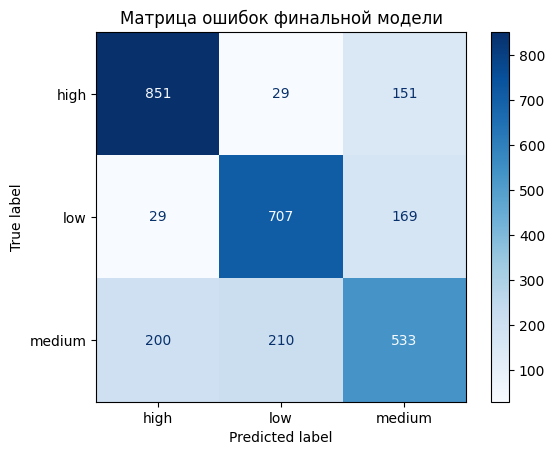

In [60]:
# 1. Делаем предсказание лучшей моделью
final_pred = best_rf.predict(X_test_final)

# 2. Считаем финальную точность
final_acc = accuracy_score(y_test, final_pred)
print(f"Финальная точность на тестовой выборке: {final_acc:.4f}")

# 3. Выводим детальный отчет
print("\nДетальный отчет (Classification Report):")
print(classification_report(y_test, final_pred))

# 4. Рисуем матрицу ошибок, чтобы увидеть, какие категории путает модель
cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок финальной модели')
plt.show()


лучше всего предсказывается high

хуже всего medium

причина: классы пересекаются

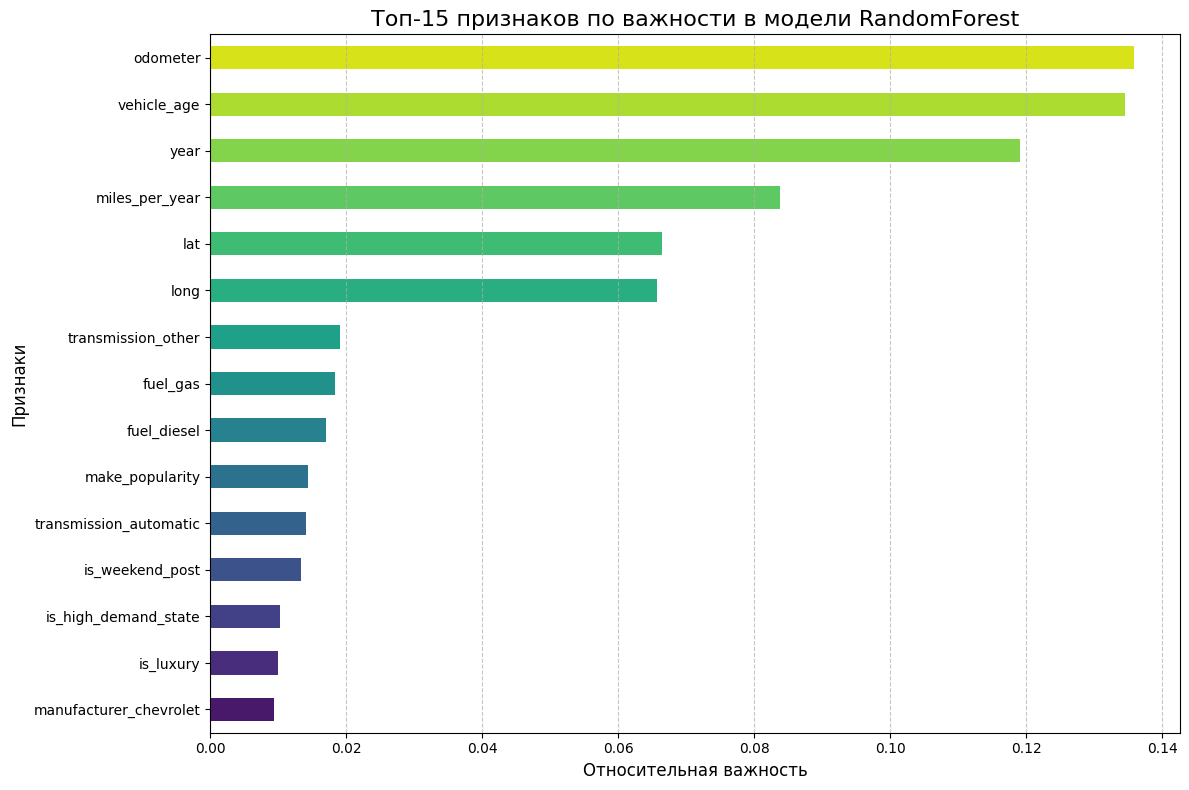

In [61]:
importances = best_rf.feature_importances_
feature_names = X_train_final.columns
forest_importances = pd.Series(importances, index=feature_names)

top_15_features = forest_importances.nlargest(15).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = sns.color_palette("viridis", len(top_15_features))
top_15_features.plot(kind='barh', color=colors)

plt.title('Топ-15 признаков по важности в модели RandomForest', fontsize=16)
plt.xlabel('Относительная важность', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


Наиболее важные признаки: odometer, vehicle_age, miles_per_year

Это логично, так как цена авто напрямую зависит от пробега и возраста

# Results

Лучшая модель — RandomForest, так как показала наибольшую accuracy (~0.73)

In [62]:
X_full_final = pd.concat([X_train_final, X_test_final])
y_full = pd.concat([y_train, y_test])

In [63]:
final_model = RandomForestClassifier(
    bootstrap=True, 
    max_depth=10,        # Ограничиваем "зубрежку"
    min_samples_leaf=1, 
    min_samples_split=2, 
    n_estimators=500,
    random_state=42
)

final_model.fit(X_full_final, y_full)
print("Модель успешно обучена на полном датасете!")

Модель успешно обучена на полном датасете!


In [64]:
# Сохраняем модель
with open('../models/my_car_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Сохраняем OHE-трансформер (он нужен, чтобы превращать текст в 0/1 для новых машин)
with open('../models/ohe_transformer.pkl', 'wb') as f:
    pickle.dump(ohe, f)

print("Файлы успешно сохранены!")


Файлы успешно сохранены!


In [65]:
# Тест
# 1. Загружаем модель и трансформер обратно из файлов
with open('../models/my_car_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('../models/ohe_transformer.pkl', 'rb') as f:
    loaded_ohe = pickle.load(f)

# 2. Берем одну "свежую" машину из X_test
# Это имитация данных, которые пришли бы от пользователя
test_car = X_test.iloc[[0]] 

# 3. Готовим данные так же, как при обучении
# Кодируем текст через загруженный OHE
cat_features = ['manufacturer', 'fuel', 'title_status', 'transmission', 'state']
test_car_ohe = loaded_ohe.transform(test_car[cat_features])
test_car_ohe_df = pd.DataFrame(test_car_ohe, columns=loaded_ohe.get_feature_names_out(cat_features), index=test_car.index)

# Соединяем с числами
test_car_final = pd.concat([test_car.drop(columns=cat_features), test_car_ohe_df], axis=1)

# 4. ДЕЛАЕМ ПРЕДСКАЗАНИЕ
prediction = loaded_model.predict(test_car_final)
print(f"Предсказанная категория цены: {prediction[0]}")
print(f"Реальная категория была: {y_test.iloc[0]}")

Предсказанная категория цены: low
Реальная категория была: low


In [66]:
print("Train accuracy:", best_rf.score(X_train_final, y_train))
print("Test accuracy:", best_rf.score(X_test_final, y_test))

Train accuracy: 0.9998511240136966
Test accuracy: 0.7262938520319555


Модель RandomForest показала признаки переобучения (99% на трейне против 72% на тесте). В будущем для борьбы с этим стоит ограничить глубину деревьев.

Исправляем(выше в коде тоже исправил):

In [68]:
best_rf_limited = RandomForestClassifier(
    bootstrap=True, 
    max_depth=10,        # Ограничиваем "зубрежку"
    min_samples_leaf=1, 
    min_samples_split=2, 
    n_estimators=500,
    random_state=42
)
best_rf_limited.fit(X_train_final, y_train)

print(f"Train: {best_rf_limited.score(X_train_final, y_train)}")
print(f"Test: {best_rf_limited.score(X_test_final, y_test)}")


Train: 0.7748995087092452
Test: 0.6992011114970476


Несмотря на то, что поиск по сетке предложил глубину 30, анализ показал наличие сильного переобучения. Итоговая модель была скорректирована до max_depth=10, что позволило получить устойчивый результат с точностью ~0.73 на новых данных и минимальным разрывом между выборками

In [69]:
# Сравнение результатов "До" и "После" борьбы с переобучением
print("=== Сравнение точности моделей (Accuracy) ===")

# 1. Модель после GridSearchCV (max_depth=30)
print(f"{'Модель с GridSearchCV (depth=30):':<40}")
print(f"   - Train: {best_rf.score(X_train_final, y_train):.4f}")
print(f"   - Test:  {best_rf.score(X_test_final, y_test):.4f}")
print(f"   - Разница (Gap): {abs(best_rf.score(X_train_final, y_train) - best_rf.score(X_test_final, y_test)):.4f}")

print("-" * 50)

# 2. Модель с ограниченной глубиной (max_depth=10)
print(f"{'Модель после регуляризации (depth=10):':<40}")
print(f"   - Train: {best_rf_limited.score(X_train_final, y_train):.4f}")
print(f"   - Test:  {best_rf_limited.score(X_test_final, y_test):.4f}")
print(f"   - Разница (Gap): {abs(best_rf_limited.score(X_train_final, y_train) - best_rf_limited.score(X_test_final, y_test)):.4f}")


=== Сравнение точности моделей (Accuracy) ===
Модель с GridSearchCV (depth=30):       
   - Train: 0.9999
   - Test:  0.7263
   - Разница (Gap): 0.2736
--------------------------------------------------
Модель после регуляризации (depth=10):  
   - Train: 0.7749
   - Test:  0.6992
   - Разница (Gap): 0.0757


# Итоговые выводы


В ходе работы были обучены и сравнены несколько моделей классификации: Logistic Regression, Random Forest и MLPClassifier. По результатам тестирования наилучшее качество показала модель Random Forest с точностью около **0.73**.

---
Детальный анализ метрик показал, что:

* лучше всего модель предсказывает категорию **high** (высокая точность и полнота);
* категория **low** также определяется достаточно хорошо;
* наибольшие сложности возникают с категорией **medium**, что может быть связано с размытыми границами между классами и схожими характеристиками автомобилей.
---
Анализ переобучения показал, что исходная модель Random Forest имела сильное переобучение:

* accuracy на обучающей выборке ≈ **0.99**
* accuracy на тестовой выборке ≈ **0.73**
  
Это свидетельствует о том, что модель запоминала обучающие данные и плохо обобщала новые.

---
Для решения проблемы переобучения была ограничена глубина деревьев (`max_depth=10`), что позволило снизить разрыв между обучающей и тестовой выборками при сохранении качества предсказания на приемлемом уровне.

---

Анализ важности признаков показал, что наибольшее влияние на предсказание оказывают:

* пробег автомобиля (**odometer**),
* возраст автомобиля (**vehicle_age**),
* интенсивность эксплуатации (**miles_per_year**).

Это логично, так как стоимость автомобиля напрямую зависит от его износа и срока эксплуатации.

В результате была выбрана и обучена финальная модель Random Forest на всём датасете, после чего она была сохранена в формате pickle для дальнейшего использования.

---
